Week 1&2

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/netflix_titles.csv")
# Basic info
print("Shape of dataset:", df.shape)
print("\nColumn Info:")
print(df.info())

Shape of dataset: (8807, 12)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [2]:
# Check null values column-wise
null_values = df.isnull().sum()
print("Null Values in Each Column:\n")
print(null_values)

Null Values in Each Column:

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [3]:
#Check Null Values
print("Null Values Before Handling:\n")
print(df.isnull().sum())

# Fill director, cast, countr,rating with "Unknown","Not Available"...
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Not Available")
df['country'] = df['country'].fillna("Not Available")
df['rating'] = df['rating'].fillna("not Rated")



#Drop Very Small Null Rows
df=df.dropna(subset=['duration'])
df = df.dropna(subset=['date_added'])

#Final Check
print("\nNull Values After Handling:\n")
print(df.isnull().sum())

print("\nFinal Dataset Shape:", df.shape)

Null Values Before Handling:

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Null Values After Handling:

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Final Dataset Shape: (8794, 12)


In [4]:
#Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


In [5]:
#Check duplicates based on title
print("Duplicate Titles:", df.duplicated(subset=['title']).sum())

Duplicate Titles: 0


In [6]:
#conversion of datatype
print("Before Conversion:", df['release_year'].dtype)
print("Before Conversion:", df['date_added'].dtype)

Before Conversion: int64
Before Conversion: object


In [7]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['release_year'] = pd.to_datetime(df['release_year'], format='%Y')

In [8]:
print("After Conversion:")
print("release_year datatype:", df['release_year'].dtype)
print("date_added datatype:", df['date_added'].dtype)

After Conversion:
release_year datatype: datetime64[ns]
date_added datatype: datetime64[ns]


In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 8794 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8794 non-null   object        
 1   type          8794 non-null   object        
 2   title         8794 non-null   object        
 3   director      8794 non-null   object        
 4   cast          8794 non-null   object        
 5   country       8794 non-null   object        
 6   date_added    8706 non-null   datetime64[ns]
 7   release_year  8794 non-null   datetime64[ns]
 8   rating        8794 non-null   object        
 9   duration      8794 non-null   object        
 10  listed_in     8794 non-null   object        
 11  description   8794 non-null   object        
dtypes: datetime64[ns](2), object(10)
memory usage: 893.1+ KB
None


In [10]:
#Column Name Inconsistency Check
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [11]:
#Case Inconsistency
print(df['type'].unique())
print(df['rating'].unique())

['Movie' 'TV Show']
['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' 'NR' 'not Rated' 'TV-Y7-FV' 'UR']


In [12]:
df['rating'] = df['rating'].replace({'UR': 'NR'})

In [13]:
df['rating'] = df['rating'].replace({'NR': 'not Rated'})
print(df['rating'].unique())

['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' 'not Rated' 'TV-Y7-FV']


In [14]:
#Check Numeric Column Consistency
print("Min Year:", df['release_year'].min())
print("Max Year:", df['release_year'].max())

Min Year: 1925-01-01 00:00:00
Max Year: 2021-01-01 00:00:00


In [15]:
#Check Logical Category Errors
expected_types = ['Movie', 'TV Show']
print("Unexpected Type Values:",
      set(df['type']) - set(expected_types))

Unexpected Type Values: set()


Week 3&4


In [16]:
#Categorical Columns Identification
categorical_columns = df.select_dtypes(include='object').columns
print("Categorical Columns:", categorical_columns)

Categorical Columns: Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'rating',
       'duration', 'listed_in', 'description'],
      dtype='object')


In [17]:
#Check Unique Values
for col in ['type','country','rating','listed_in']:
    print("\n",col)
    print(df[col].value_counts().head())


 type
type
Movie      6128
TV Show    2666
Name: count, dtype: int64

 country
country
United States     2809
India              972
Not Available      830
United Kingdom     418
Japan              244
Name: count, dtype: int64

 rating
rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
Name: count, dtype: int64

 listed_in
listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Name: count, dtype: int64


In [18]:
#Standardize Column Names
df.columns = df.columns.str.lower().str.strip()

In [19]:
#Convert Categorical Columns to Lowercase
cols_lower = ['type','director','cast','country','rating','listed_in']
for col in cols_lower:
    df[col] = df[col].str.lower()

In [20]:
#checking whether categorical columns converted into lowercase
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    check = (df[col] == df[col].str.lower()).all()
    print(col, ":", check)

show_id : True
type : True
title : False
director : True
cast : True
country : True
rating : True
duration : False
listed_in : True
description : False


In [21]:
#checking unwanted spaces cleared or not
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(col, "leading spaces:", df[col].str.startswith(' ').sum())

show_id leading spaces: 0
type leading spaces: 0
title leading spaces: 0
director leading spaces: 0
cast leading spaces: 0
country leading spaces: 0
rating leading spaces: 0
duration leading spaces: 0
listed_in leading spaces: 0
description leading spaces: 0


In [22]:
#Standardize Duration Column
df['duration'].unique()

array(['90 min', '2 Seasons', '1 Season', '91 min', '125 min',
       '9 Seasons', '104 min', '127 min', '4 Seasons', '67 min', '94 min',
       '5 Seasons', '161 min', '61 min', '166 min', '147 min', '103 min',
       '97 min', '106 min', '111 min', '3 Seasons', '110 min', '105 min',
       '96 min', '124 min', '116 min', '98 min', '23 min', '115 min',
       '122 min', '99 min', '88 min', '100 min', '6 Seasons', '102 min',
       '93 min', '95 min', '85 min', '83 min', '113 min', '13 min',
       '182 min', '48 min', '145 min', '87 min', '92 min', '80 min',
       '117 min', '128 min', '119 min', '143 min', '114 min', '118 min',
       '108 min', '63 min', '121 min', '142 min', '154 min', '120 min',
       '82 min', '109 min', '101 min', '86 min', '229 min', '76 min',
       '89 min', '156 min', '112 min', '107 min', '129 min', '135 min',
       '136 min', '165 min', '150 min', '133 min', '70 min', '84 min',
       '140 min', '78 min', '7 Seasons', '64 min', '59 min', '139 min',
    

In [23]:
#Create duration_minutes
df['duration_minutes'] = df['duration'].apply(
    lambda x: x.split()[0] if 'min' in str(x).lower() else None
)

In [24]:
#Create duration_seasons
df['duration_seasons'] = df['duration'].apply(
    lambda x: x.split()[0] if 'season' in str(x).lower() else None
)

In [25]:
#Check Split Result
df[['duration','duration_minutes','duration_seasons']].head(10)

,duration,duration_minutes,duration_seasons
0,90 min,90,None
1,2 Seasons,None,2
2,1 Season,None,1
3,1 Season,None,1
4,2 Seasons,None,2
5,1 Season,None,1
6,91 min,91,None
7,125 min,125,None
8,9 Seasons,None,9
9,104 min,104,None


In [26]:
#Fill Null Values with "not available"
df['duration_minutes'] = df['duration_minutes'].fillna("not available")
df['duration_seasons'] = df['duration_seasons'].fillna("not available")

In [27]:
#check for null values
df[['duration_minutes','duration_seasons']].isnull().sum()

,0
duration_minutes,0
duration_seasons,0


In [28]:
#Check Duplicates
df[['duration_minutes','duration_seasons']].duplicated().sum()

np.int64(8574)

In [29]:
df = df.drop_duplicates(subset=['duration_minutes','duration_seasons'])

In [30]:
df[['duration_minutes','duration_seasons']].duplicated().sum()

np.int64(0)

In [31]:
df[['duration','duration_minutes','duration_seasons']].head(10)

,duration,duration_minutes,duration_seasons
0,90 min,90,not available
1,2 Seasons,not available,2
2,1 Season,not available,1
6,91 min,91,not available
7,125 min,125,not available
8,9 Seasons,not available,9
9,104 min,104,not available
12,127 min,127,not available
15,4 Seasons,not available,4
16,67 min,67,not available


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
#Count content added each year
content_growth = df['release_year'].value_counts().sort_index()
content_growth

,count
release_year,
1942-01-01,1
1961-01-01,1
1963-01-01,1
1964-01-01,2
1965-01-01,1
1973-01-01,1
1975-01-01,1
1978-01-01,1
1979-01-01,1


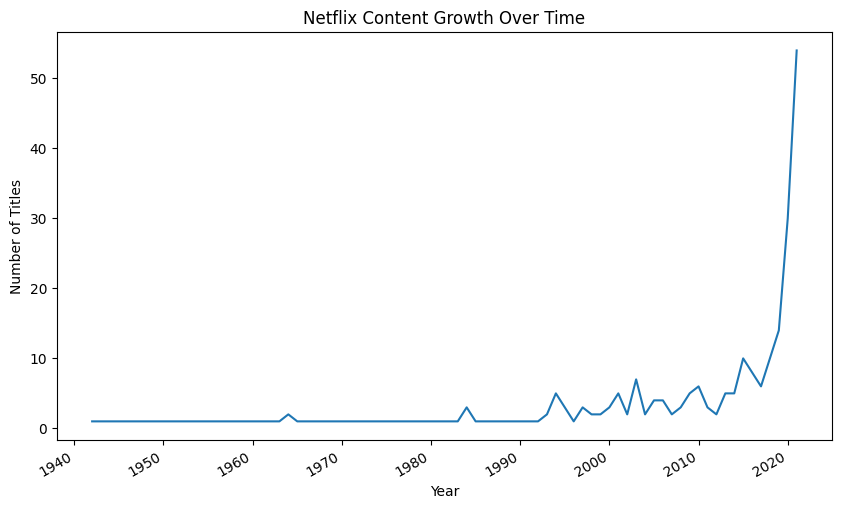

In [34]:
#Plot growth of Netflix content
plt.figure(figsize=(10,6))
content_growth.plot(kind='line')

plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

In [35]:
df['type'].value_counts()

,count
type,
movie,205
tv show,15


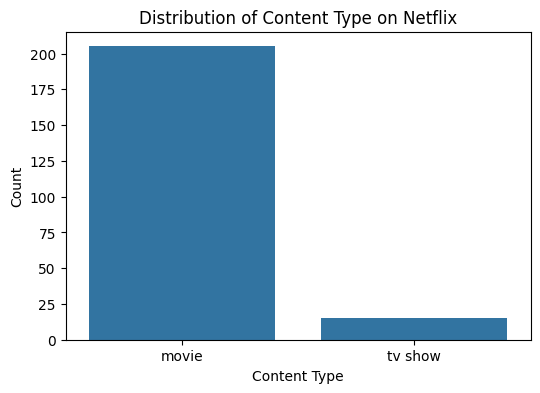

In [36]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)

plt.title("Distribution of Content Type on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

In [37]:
df['rating'].value_counts()

,count
rating,
tv-14,71
tv-ma,43
tv-pg,25
pg-13,20
r,17
tv-y,15
pg,9
tv-g,9
tv-y7,8


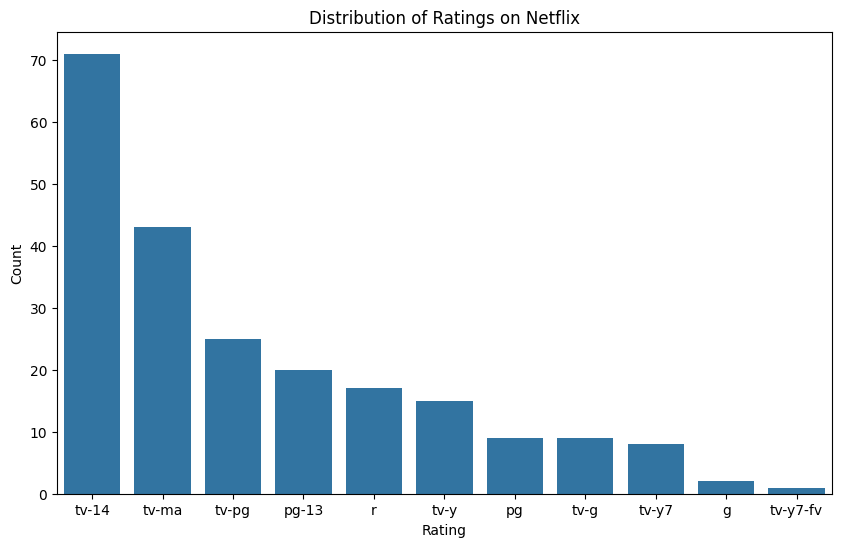

In [38]:
plt.figure(figsize=(10,6))

sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index)

plt.title("Distribution of Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

In [39]:
df['listed_in'].value_counts().head(10)

,count
listed_in,
children & family movies,14
"dramas, international movies",14
documentaries,11
"comedies, dramas, international movies",10
"action & adventure, dramas, international movies",9
"action & adventure, anime features, international movies",9
"children & family movies, comedies",8
"documentaries, international movies",7
comedies,6


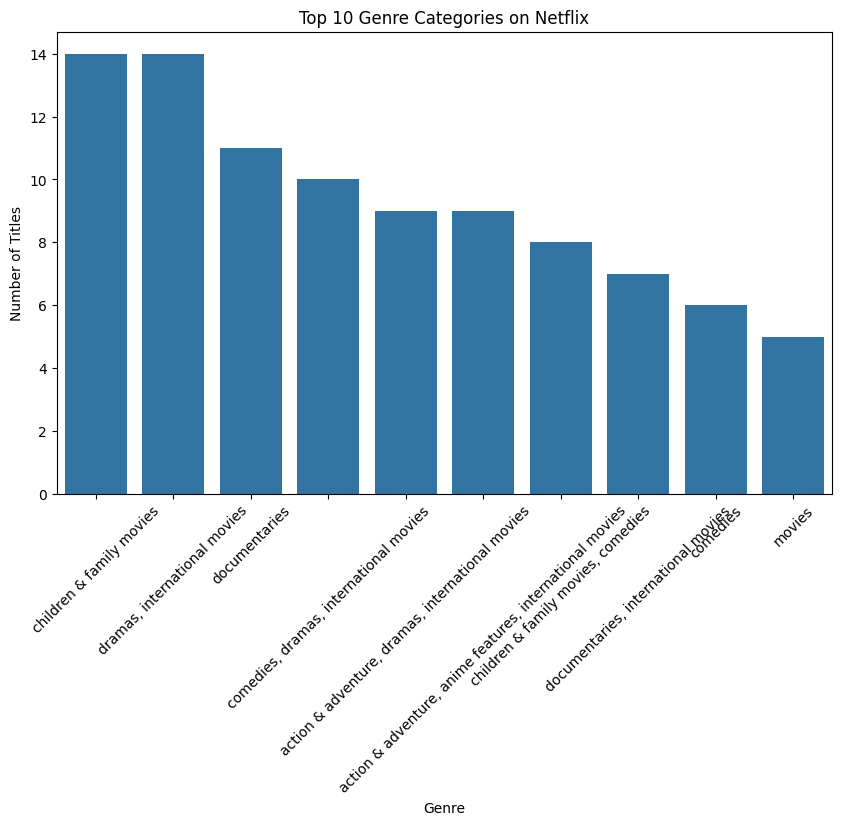

In [40]:
top_genres = df['listed_in'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_genres.index, y=top_genres.values)

plt.title("Top 10 Genre Categories on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

In [41]:
#Analyze Country-Level Content Contributions
df['country'].value_counts().head(10)

,count
country,
not available,65
united states,52
india,33
japan,10
egypt,5
canada,5
united kingdom,3
"united states, canada",3
nigeria,2


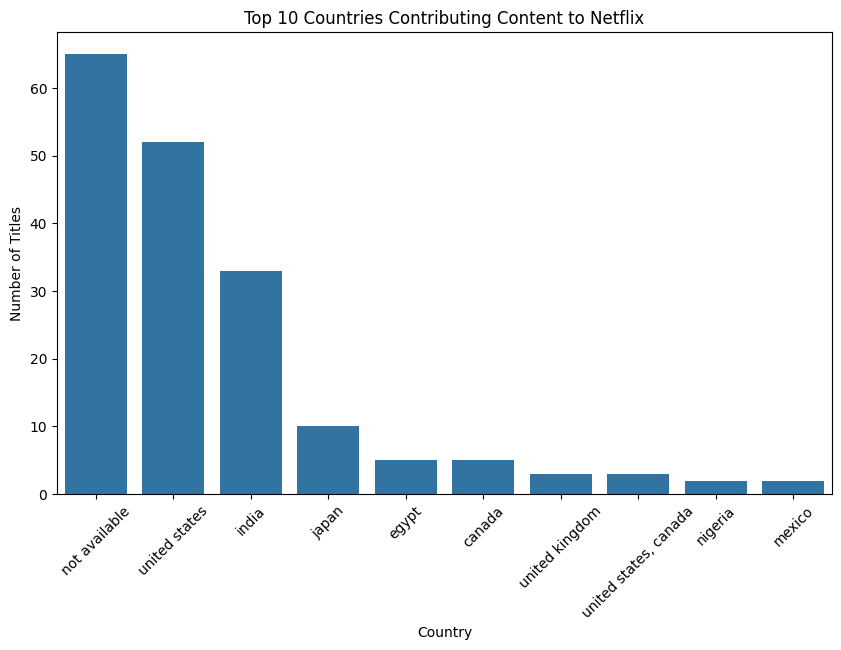

In [42]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_countries.index, y=top_countries.values)

plt.title("Top 10 Countries Contributing Content to Netflix")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

In [43]:
#Create Derived Feature: Content Length Category
def length_category(x):
    if x == "not available":
        return "not available"
    x = float(x)
    if x < 60:
        return "short"
    elif x <= 120:
        return "medium"
    else:
        return "long"

df['content_length_category'] = df['duration_minutes'].apply(length_category)

In [44]:
df[['duration_minutes','content_length_category']].head()

,duration_minutes,content_length_category
0,90,medium
1,not available,not available
2,not available,not available
6,91,medium
7,125,long


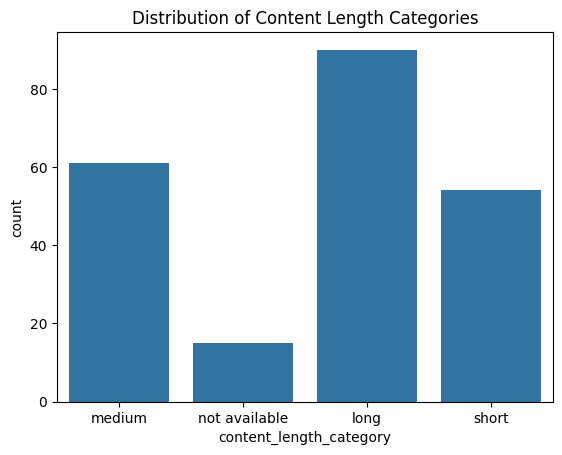

In [45]:
#Distribution of Content Length Category
sns.countplot(x='content_length_category', data=df)

plt.title("Distribution of Content Length Categories")
plt.show()

In [46]:
df['added_year'] = df['date_added'].dt.year
df['year_difference'] = df['added_year'] - df['release_year'].dt.year
df['Original_vs_Licensed'] = df['year_difference'].apply(
    lambda x: 'Original' if x <= 1 else 'Licensed')
print(df['Original_vs_Licensed'].value_counts())

Original_vs_Licensed
Licensed    126
Original     94
Name: count, dtype: int64


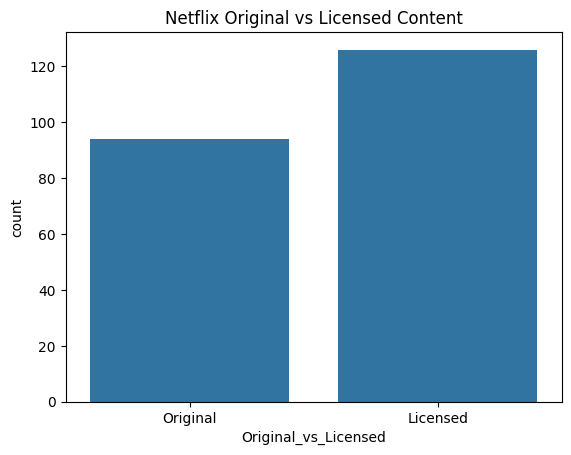

In [47]:
sns.countplot(x='Original_vs_Licensed', data=df)
plt.title("Netflix Original vs Licensed Content")
plt.show()

Week 5&6


In [48]:
#Clustering Netflix Titles
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['rating_encoded'] = le.fit_transform(df['rating'])

In [49]:
cluster_data = df[['rating_encoded']].copy()

In [50]:
#Apply K-Means clustering.
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

df['cluster'] = kmeans.fit_predict(cluster_data)

In [51]:
#Check clusters
df[['rating','cluster']].head()

,rating,cluster
0,pg-13,1
1,tv-ma,0
2,tv-ma,0
6,pg,1
7,tv-ma,0


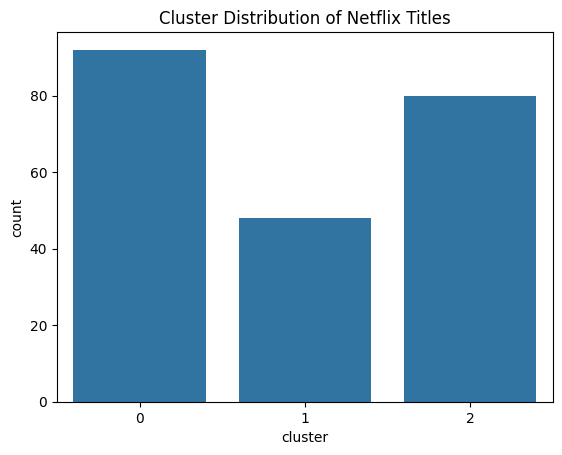

In [52]:
#Visualize Clusters
sns.countplot(x='cluster', data=df)

plt.title("Cluster Distribution of Netflix Titles")
plt.show()

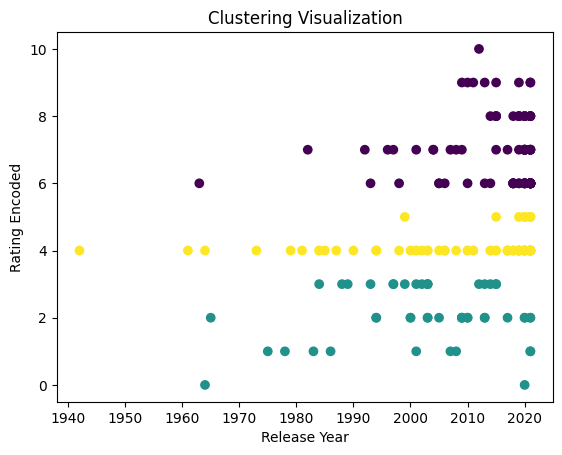

In [57]:
plt.scatter(df['release_year'], df['rating_encoded'],
            c=df['cluster'], cmap='viridis')

plt.xlabel('Release Year')
plt.ylabel('Rating Encoded')
plt.title('Clustering Visualization')

plt.show()

In [58]:
#Classification of Content Type (Movie vs TV Show)
df['type'].value_counts()

,count
type,
movie,205
tv show,15


In [59]:
#Encode target variable
df['type_encoded'] = le.fit_transform(df['type'])

In [60]:
X = df[['rating_encoded']]
y = df['type_encoded']

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)

0.9772727272727273